<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_12_3_vision_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 12: Explainability**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 12 Material

* Part 12.1: What is Explainability [[Video]]() [[Notebook]](t81_558_class_12_1_explainability.ipynb)
* Part 12.2: Feature Importance [[Video]]() [[Notebook]](t81_558_class_12_2_feature_importance.ipynb)
* **Part 12.3: Visualization for Computer Vision** [[Video]]() [[Notebook]](t81_558_class_12_3_vision_viz.ipynb)
* Part 12.4: Gradient-Based Explanations [[Video]]() [[Notebook]](t81_558_class_12_4_gradient_explain.ipynb)
* Part 12.5: Limitations of Explainability [[Video]]() [[Notebook]](t81_558_class_12_5_limitations.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 12.3: Visualization for Computer Vision

Convolutional neural networks are among the most successful and least transparent models in deep learning. A trained image classifier passes a picture through dozens of layers of convolutions before arriving at a label, and the intermediate representations are tensors with hundreds of channels that have no obvious meaning. Yet because the inputs and internal signals of a CNN are themselves images, we have a powerful advantage over the tabular case: we can *look* at what the network computes. Visualization turns the opaque internals of a vision model into pictures a human can inspect.

This section covers three complementary visualization techniques, moving from the model's fixed parameters to its response to a specific image. First we look at the learned convolutional filters, the model's most primitive building blocks. Then we visualize the feature maps, the activations produced as an image flows through the network. Finally we use occlusion sensitivity, a model-agnostic method that discovers which regions of an image the prediction actually depends on by systematically hiding parts of it.

Rather than train a network from scratch, we use a ResNet-18 that has already been trained on ImageNet, the same kind of pretrained model introduced in Module 5. This lets us study a strong, real-world classifier and see what a network learns when trained on a million images.

## A Pretrained Classifier and a Test Image

We begin by loading the pretrained ResNet-18 together with the exact preprocessing it expects, then fetching a sample image and confirming the model classifies it. Establishing the prediction first gives us a target to explain: every visualization that follows is ultimately about understanding *why* the network produced this label. The transforms bundled with the weights handle resizing, cropping, and normalization so that the image matches the distribution the model was trained on.

Top-3 predictions:
  Samoyed                0.885
  Arctic fox             0.046
  white wolf             0.044


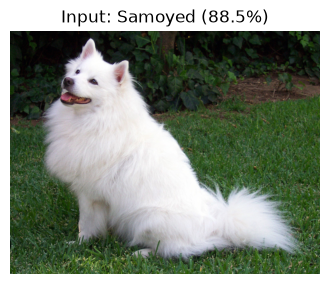

In [2]:
import io
import urllib.request
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models
from torchvision.models import ResNet18_Weights

# Load a pretrained classifier and its matching preprocessing pipeline.
weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval()
categories = weights.meta["categories"]
preprocess = weights.transforms()

# Fetch the standard PyTorch example image.
url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
img = Image.open(io.BytesIO(urllib.request.urlopen(url).read())).convert("RGB")

x = preprocess(img).unsqueeze(0)     # shape (1, 3, 224, 224)
with torch.no_grad():
    probs = F.softmax(model(x), dim=1)[0]
top = probs.topk(3)

print("Top-3 predictions:")
for p, i in zip(top.values, top.indices):
    print(f"  {categories[i]:22s} {p.item():.3f}")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Input: {categories[top.indices[0]]} ({top.values[0]:.1%})")
plt.show()

The network confidently identifies the animal. With a concrete prediction in hand, we can start opening the box, beginning with the very first thing the image encounters inside the network: the learned convolutional filters.

## Visualizing the Learned Filters

The first convolutional layer of ResNet-18 applies 64 filters, each spanning the three color channels over a 7-by-7 window. These filters are the model's most basic feature detectors, and because they operate directly on RGB pixels, we can render each one as a small color image and look at it. Decades of work on both biological and artificial vision predict what we should see: detectors for oriented edges, color contrasts, and simple textures. These low-level patterns are the alphabet from which deeper layers compose more complex concepts.

Because filter weights are not naturally in the 0-to-1 range that image display expects, we rescale them to that range before plotting.

conv1 weight shape: (64, 3, 7, 7)


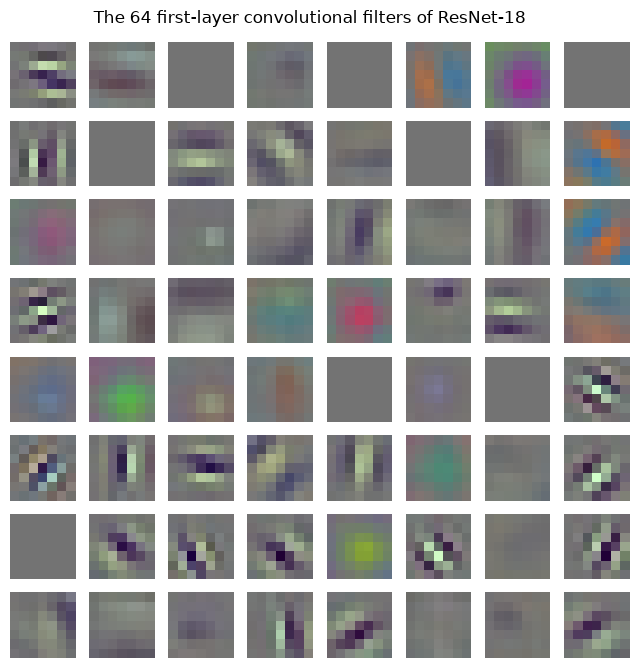

In [3]:
# conv1 has shape (64, 3, 7, 7): 64 filters, each 3 channels x 7 x 7.
filters = model.conv1.weight.detach().clone()
print("conv1 weight shape:", tuple(filters.shape))

# Normalize all filters jointly to [0, 1] so they can be shown as RGB images.
filters = (filters - filters.min()) / (filters.max() - filters.min())

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filters[i].permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("The 64 first-layer convolutional filters of ResNet-18", y=0.92)
plt.show()

The grid confirms the prediction. Many filters are oriented edge detectors, bright on one side and dark on the other along a particular direction, while others are blobs of opposing colors that respond to color contrasts such as green-against-magenta. These are exactly the primitive features one expects at the input of a vision system, and the network discovered them on its own from ImageNet. Filters this interpretable are unique to the first layer; deeper filters operate on abstract feature channels rather than RGB pixels, so we cannot simply plot them as images. To see what the deeper layers do, we instead look at their activations.

## Visualizing Feature Maps

When an image passes through the network, each convolutional layer produces a stack of **feature maps**, one per output channel. A feature map is a spatial grid showing how strongly that channel's detector responded at each location in the image. Visualizing these activations reveals what the network is picking out from *this particular image*, as opposed to the fixed filters, which are the same for every input.

We capture the feature maps with a forward hook, the same technique from the debugging section in Module 11, attached to an early residual block. Each channel is displayed as a heatmap, where bright regions mark where that channel activated strongly.

layer1 feature-map shape: (64, 56, 56)


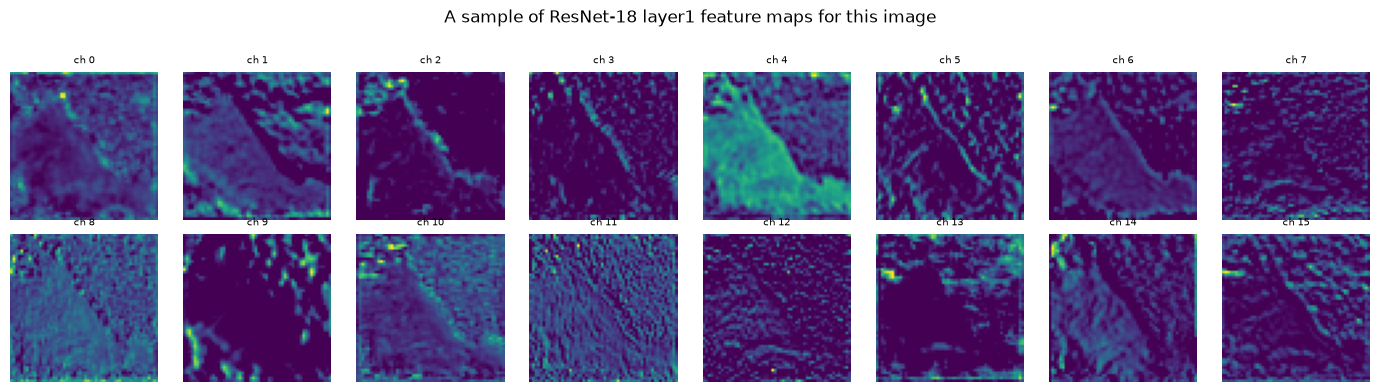

In [4]:
# A forward hook records the activations at an inner layer as the image flows through.
activations = {}
def hook(module, inputs, output):
    activations["feat"] = output.detach()

handle = model.layer1.register_forward_hook(hook)
with torch.no_grad():
    model(x)
handle.remove()

feature_maps = activations["feat"][0]     # shape (64, 56, 56)
print("layer1 feature-map shape:", tuple(feature_maps.shape))

fig, axes = plt.subplots(2, 8, figsize=(14, 3.8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(feature_maps[i].numpy(), cmap="viridis")
    ax.set_title(f"ch {i}", fontsize=7)
    ax.axis("off")
fig.suptitle("A sample of ResNet-18 layer1 feature maps for this image", y=1.02)
plt.tight_layout()
plt.show()

Even at this early layer, the feature maps retain a recognizable spatial layout of the image, and different channels emphasize different aspects: some light up along the animal's outline, others respond to the textured background, and still others to regions of uniform color. Each channel is a different learned filter reporting where its pattern appears. As we go deeper into the network these maps become smaller and more abstract, trading spatial detail for semantic content, until the final layers respond to whole-object concepts rather than local textures. Feature maps show us *what* the network detects and *where*, but they do not directly tell us which regions were decisive for the final label. For that, we turn to occlusion.

## Occlusion Sensitivity

Occlusion sensitivity answers a direct question: if we hide part of the image, does the prediction suffer? The method slides an occluding patch across the image, and at each position it blanks out that region, runs the network, and records how far the probability of the predicted class falls. Regions that cause a large drop when hidden are regions the model depends on; regions that make no difference are irrelevant to the decision. Assembling these drops into a grid produces a heatmap of importance over the image.

Unlike the filter and feature-map views, occlusion is completely model-agnostic. It never looks inside the network; it only queries the output for many masked versions of the input. That generality is appealing, but it comes at a cost, one forward pass per patch position, which is why the gradient-based methods in the next section were developed as a faster alternative.

169 forward passes; max probability drop = 0.409


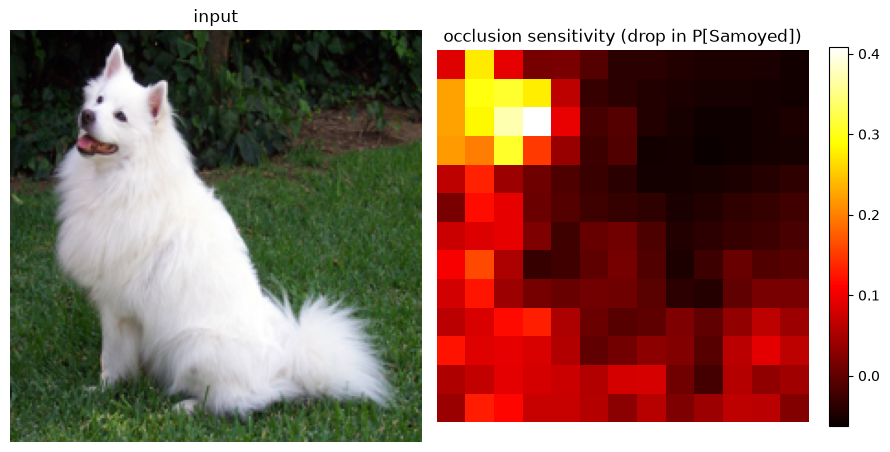

In [5]:
# Slide a patch over the image; record the drop in the target class probability.
target = top.indices[0].item()
base_prob = probs[target].item()
patch, stride = 32, 16
_, _, H, W = x.shape

rows = range(0, H - patch + 1, stride)
cols = range(0, W - patch + 1, stride)
heatmap = np.zeros((len(rows), len(cols)))

with torch.no_grad():
    for r, y0 in enumerate(rows):
        for c, x0 in enumerate(cols):
            occluded = x.clone()
            occluded[:, :, y0:y0 + patch, x0:x0 + patch] = 0.0
            p = F.softmax(model(occluded), dim=1)[0, target].item()
            heatmap[r, c] = base_prob - p

print(f"{len(rows) * len(cols)} forward passes; "
      f"max probability drop = {heatmap.max():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img.resize((224, 224)))
ax[0].axis("off")
ax[0].set_title("input")
im = ax[1].imshow(heatmap, cmap="hot")
ax[1].axis("off")
ax[1].set_title(f"occlusion sensitivity (drop in P[{categories[target]}])")
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout()
plt.show()

The heatmap concentrates over the animal itself: hiding the head and body sharply reduces the model's confidence, while occluding the background barely moves it. This is reassuring evidence that the classifier is looking at the object rather than at some incidental cue in the background, exactly the kind of check that occlusion is good for. Had the hot region fallen on the background instead, it would be a warning that the model had learned a spurious correlation.

Occlusion gave us a faithful, easy-to-trust importance map, but at the price of running the network more than a hundred times for a single image, and the resolution is limited by the patch and stride we chose. The next section, [Gradient-Based Explanations](t81_558_class_12_4_gradient_explain.ipynb), achieves a similar localization from a single backward pass by using the gradients the network already computes.